=== AR(12) + RandomForest テスト性能 ===
MAE : 653.3110980638727
RMSE: 716.2089436486397
R2  : -4.991476378866015

=== RandomForest 特徴量重要度（大きい順） ===
     lag_1 : 0.295928
     lag_7 : 0.201708
     lag_5 : 0.162108
     lag_6 : 0.142140
     lag_4 : 0.063935
     lag_3 : 0.043774
     lag_2 : 0.032050
     lag_8 : 0.020695
    lag_11 : 0.012749
    lag_10 : 0.010179
    lag_12 : 0.010138
     lag_9 : 0.004595


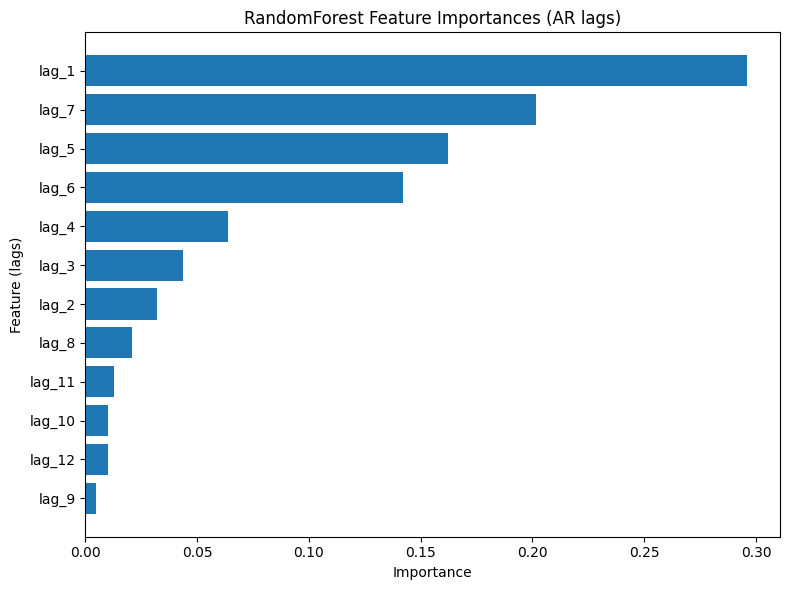

In [1]:
# ===== 設定（ここだけ変更すればOK） =====
CSV_PATH = "monthly_1950-01_2020-07.csv"  # ファイルパス
P = 12                    # ラグ数
TEST_RATIO = 0.2
SEED = 0
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# --- データ読み込み ---
df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")
y = df["Price"].astype(float)

# --- ラグ生成 ---
def make_lag_df(series, p):
    d = pd.DataFrame({"y": series})
    for k in range(1, p + 1):
        d[f"lag_{k}"] = series.shift(k)
    return d.dropna()

lagdf = make_lag_df(y, P)

X = lagdf.drop(columns=["y"]).values
target = lagdf["y"].values
dates = lagdf.index
feature_names = list(lagdf.drop(columns=["y"]).columns)

# --- 時系列分割 ---
n = len(lagdf)
split = int(n * (1 - TEST_RATIO))
X_train, X_test = X[:split], X[split:]
y_train, y_test = target[:split], target[split:]
dates_test = dates[split:]

# --- ARモデル学習（Random Forest 回帰） ---
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=SEED,
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("=== AR({}) + RandomForest テスト性能 ===".format(P))
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

# --- 特徴量重要度（Feature Importance） ---
importances = model.feature_importances_
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance")

print("\n=== RandomForest 特徴量重要度（大きい順） ===")
for _, row in imp_df.sort_values("importance", ascending=False).iterrows():
    print(f"{row['feature']:>10s} : {row['importance']:.6f}")

# --- プロット（特徴量重要度） ---
plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.title("RandomForest Feature Importances (AR lags)")
plt.xlabel("Importance")
plt.ylabel("Feature (lags)")
plt.tight_layout()
plt.show()